In [3]:
#customer segmentation with K-means
!pip install scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import joblib

In [5]:
#load rfm dta
rfm = pd.read_csv('features_rfm.csv')
print(f"Loaded {len(rfm)} customers")
rfm.head()

Loaded 4288 customers


,CustomerID,Recency,Frequency,Monetary,R_Quartile,F_Quartile,M_Quartile,RFM_Score
0,12347.0,2,7,4310.00,4,4,4,444
1,12348.0,75,4,1797.24,2,3,4,234
2,12349.0,19,1,1757.55,3,1,4,314
3,12350.0,310,1,334.40,1,1,2,112
4,12352.0,36,8,2506.04,3,4,4,344


In [6]:
# 1.prepare data for clustering
#select features for clustering

features = rfm[['Recency', 'Frequency', 'Monetary']].copy()

features.describe()

,Recency,Frequency,Monetary
count,4288.000000,4288.000000,4288.000000
mean,93.432369,3.827659,1367.080568
std,100.083346,4.782648,1952.196199
min,1.000000,1.000000,2.900000
25%,18.000000,1.000000,305.080000
50%,52.000000,2.000000,659.145000
75%,144.000000,4.000000,1592.390000
max,374.000000,93.000000,16387.570000


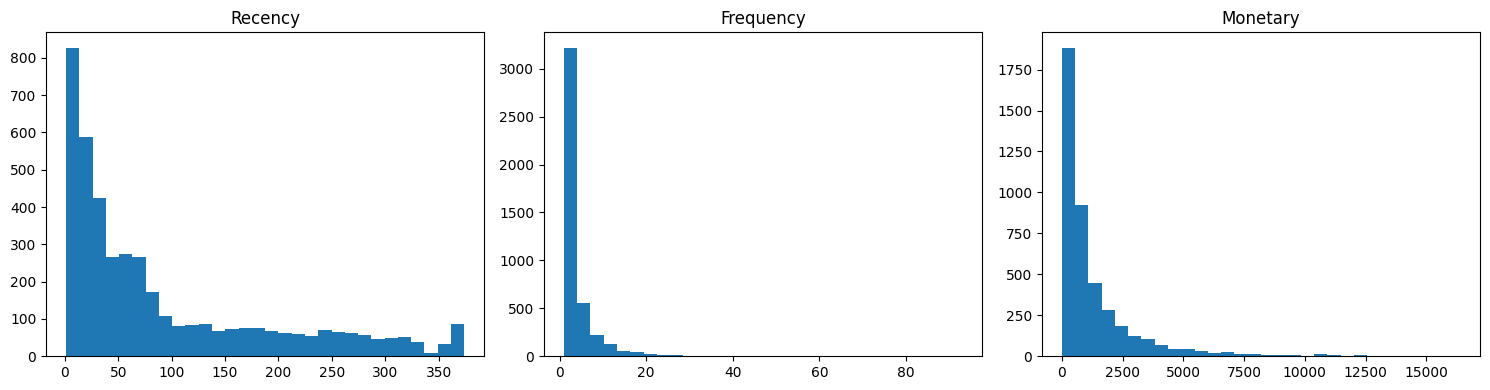

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(features['Recency'], bins=30)
axes[0].set_title('Recency')
axes[1].hist(features['Frequency'], bins=30)
axes[1].set_title('Frequency')
axes[2].hist(features['Monetary'], bins=30)
axes[2].set_title('Monetary')
plt.tight_layout()
plt.show()

In [10]:
# 2. scale the features
# StandardScaler makes all features have mean=0, std=1

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [13]:
#convert back to dataframe
scaled_df = pd.DataFrame(scaled_features, columns=['Recency', 'Frequency', 'Monetary'])

print("After scaling (mean near 0, std near 1): ")
print(scaled_df.describe().round(2))

After scaling (mean near 0, std near 1): 
       Recency  Frequency  Monetary
count  4288.00    4288.00   4288.00
mean      0.00       0.00      0.00
std       1.00       1.00      1.00
min      -0.92      -0.59     -0.70
25%      -0.75      -0.59     -0.54
50%      -0.41      -0.38     -0.36
75%       0.51       0.04      0.12
max       2.80      18.65      7.70


In [17]:
# 3. find optimal number of clusters

#method 1 ---> eldow method
inertias = []
silhouette_scores = []
K_range = range(2, 9)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(scaled_features, kmeans.labels_))

    print(f"k={k}: Inertia={kmeans.inertia_:.0f}")

k=2: Inertia=7843
k=3: Inertia=4496
k=4: Inertia=3275
k=5: Inertia=2801
k=6: Inertia=2393
k=7: Inertia=2007
k=8: Inertia=1751


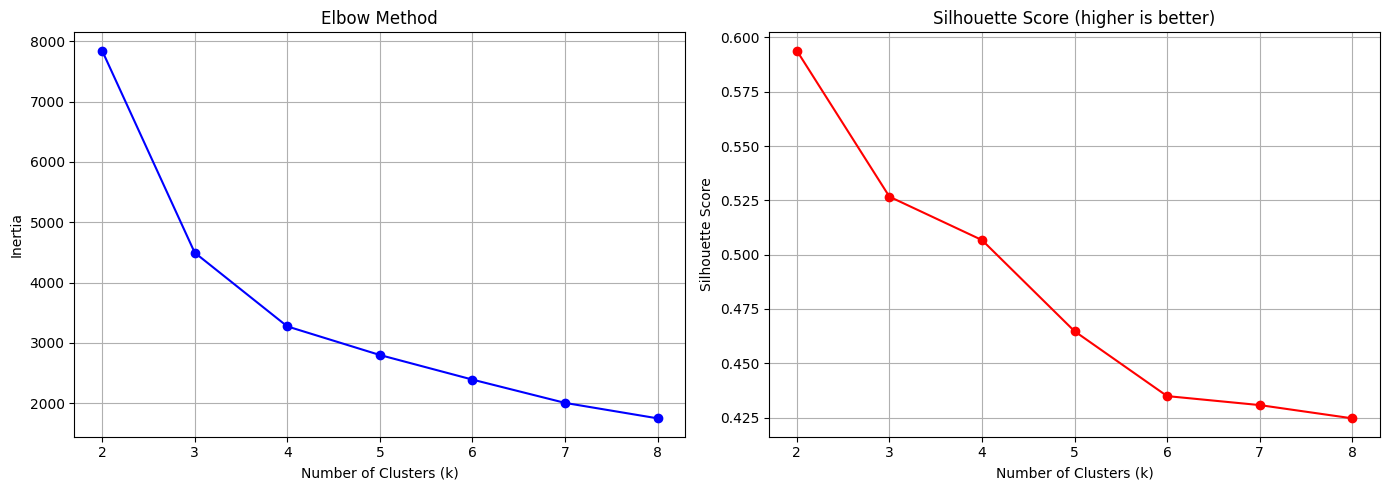

In [18]:
#plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

#elbow curve
ax1.plot(K_range, inertias, 'bo-')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')
ax1.grid(True)

# Silhouette scores
ax2.plot(K_range, silhouette_scores, 'ro-')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score (higher is better)')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [19]:
#observation : based on the elbow curve and silhouette score, k=4 seems good


In [20]:
# 4. train final model with k=4

kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(scaled_features)

#add clusters to original dataframe
rfm['Cluster'] = clusters

# Check cluster sizes
print("Cluster sizes:")
print(rfm['Cluster'].value_counts().sort_index())

Cluster sizes:
Cluster
0    2396
1    1024
2     145
3     723
Name: count, dtype: int64


In [21]:
# 5. analyze and name clusters

#calculate average rfm for each cluster
cluster_analysis = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'CustomerID': 'count'
}).round(2)

In [22]:
cluster_analysis.columns = ['Avg Recency', 'Avg Frequency', 'Avg Monetary', 'Customer Count']
cluster_analysis['Percentage'] = (cluster_analysis['Customer Count'] / cluster_analysis['Customer Count'].sum() * 100).round(1)

print("Cluster Profiles:")
print(cluster_analysis)

Cluster Profiles:
         Avg Recency  Avg Frequency  Avg Monetary  Customer Count  Percentage
Cluster                                                                      
0              50.23           2.48        746.73            2396        55.9
1             251.86           1.48        426.03            1024        23.9
2              15.50          20.94       8857.32             145         3.4
3              27.86           8.17       3253.53             723        16.9


C:\Users\User\AppData\Local\Temp\ipykernel_37376\1893133258.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(cluster_data, labels=['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3'])
C:\Users\User\AppData\Local\Temp\ipykernel_37376\1893133258.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(cluster_data, labels=['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3'])
C:\Users\User\AppData\Local\Temp\ipykernel_37376\1893133258.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(cluster_data, labels=['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3'])


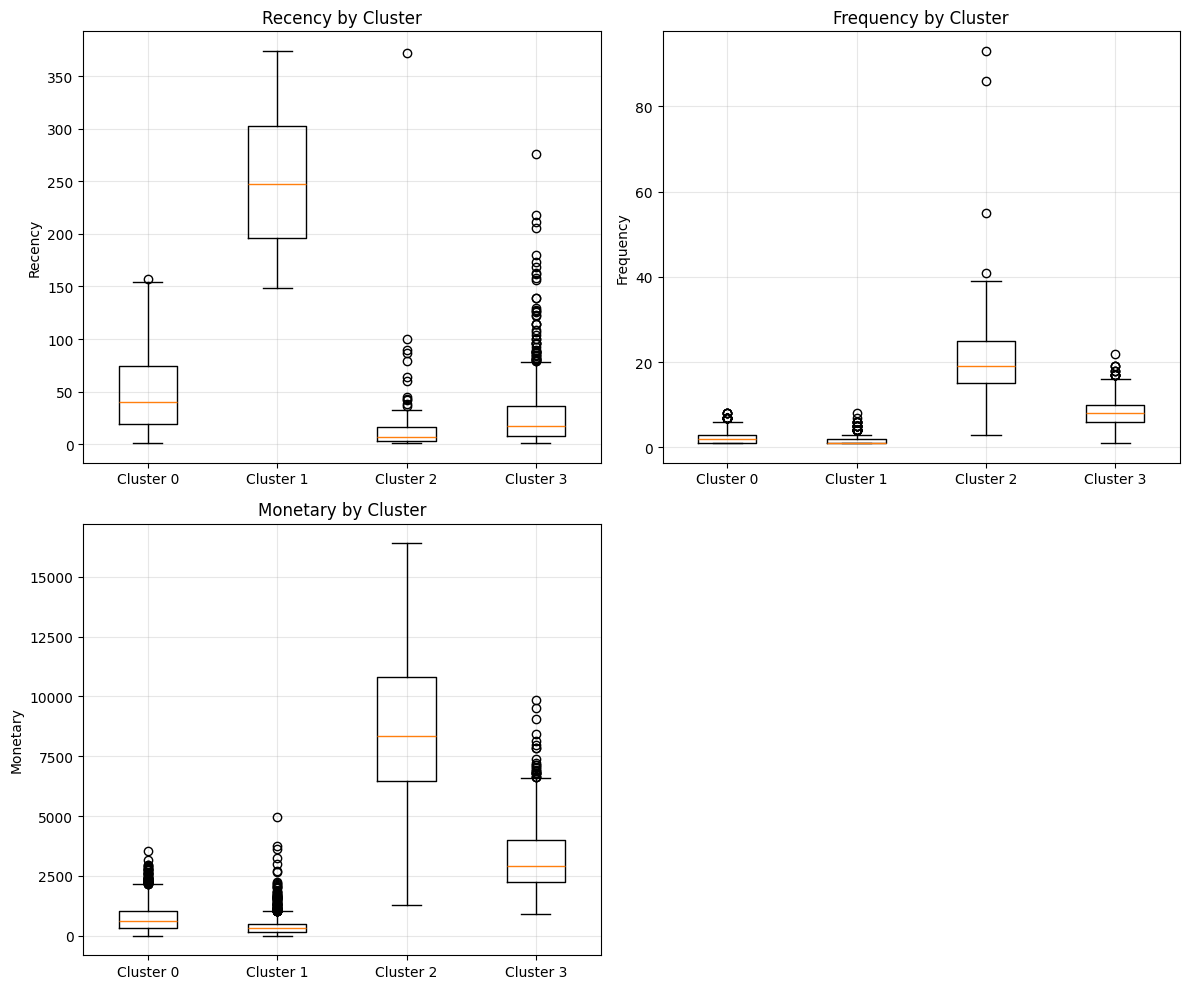

In [23]:
#visualize
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Box plots for each feature
features_to_plot = ['Recency', 'Frequency', 'Monetary']
colors = ['red', 'blue', 'green', 'orange']

for idx, feature in enumerate(features_to_plot):
    ax = axes[idx // 2, idx % 2]
    
    cluster_data = [rfm[rfm['Cluster'] == i][feature] for i in range(4)]
    bp = ax.boxplot(cluster_data, labels=['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3'])
    ax.set_title(f'{feature} by Cluster')
    ax.set_ylabel(feature)
    ax.grid(True, alpha=0.3)

# Hide the 4th subplot if not needed
if len(features_to_plot) < 4:
    axes[1, 1].set_visible(False)

plt.tight_layout()
plt.show()

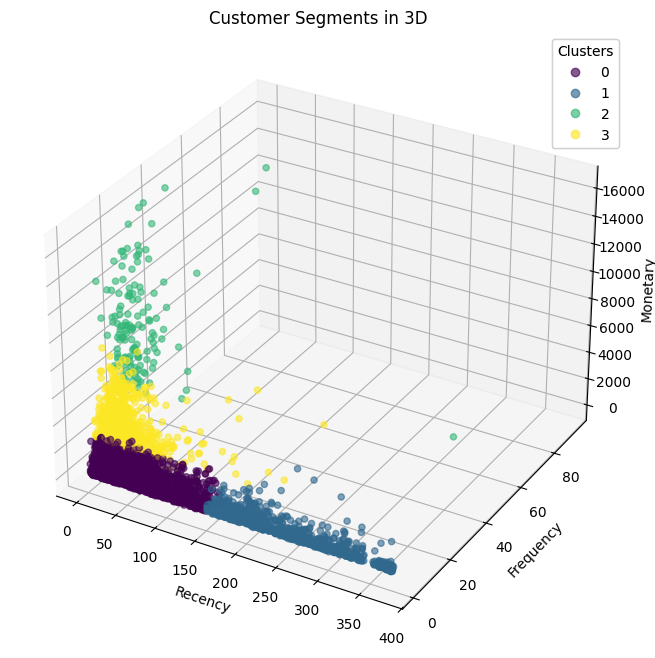

In [24]:
# Create 3D scatter plot
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(rfm['Recency'], rfm['Frequency'], rfm['Monetary'], 
                     c=rfm['Cluster'], cmap='viridis', s=20, alpha=0.6)

ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')
ax.set_title('Customer Segments in 3D')

# Add legend
legend1 = ax.legend(*scatter.legend_elements(), title="Clusters")
ax.add_artist(legend1)

plt.show()


In [25]:
# 6. name the segments

cluster_mapping = {
    0: 'At-Risk Customers',    # High recency (long time no purchase), low frequency, low monetary
    1: 'VIP Customers',         # Low recency, high frequency, high monetary
    2: 'Loyal Regulars',        # Medium recency, medium frequency, medium monetary
    3: 'New/Occasional'         # Medium recency, low frequency, low monetary
}

rfm['Segment'] = rfm['Cluster'].map(cluster_mapping)

print("\nSegment Distribution:")
print(rfm['Segment'].value_counts())


Segment Distribution:
Segment
At-Risk Customers    2396
VIP Customers        1024
New/Occasional        723
Loyal Regulars        145
Name: count, dtype: int64


In [26]:
# final segment profiles
segment_profile = rfm.groupby('Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean', 
    'Monetary': 'mean',
    'CustomerID': 'count'
}).round(2)

segment_profile['Avg Order Value'] = (segment_profile['Monetary'] / segment_profile['Frequency']).round(2)
segment_profile

,Recency,Frequency,Monetary,CustomerID,Avg Order Value
Segment,,,,,
At-Risk Customers,50.23,2.48,746.73,2396,301.10
Loyal Regulars,15.50,20.94,8857.32,145,422.99
New/Occasional,27.86,8.17,3253.53,723,398.23
VIP Customers,251.86,1.48,426.03,1024,287.86


In [28]:
# 7. save the model

joblib.dump(kmeans_final, 'models/kmeans_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')

print("Models saved to 'models/' folder")

rfm[['CustomerID', 'Cluster', 'Segment']].to_csv('customer_segments.csv', index=False)

Models saved to 'models/' folder


In [45]:
# testing

# Load models
kmeans = joblib.load('models/kmeans_model.pkl')
scaler = joblib.load('models/scaler.pkl')

# Test a customer
test_customer = pd.DataFrame({
    'Recency': [200],      # Bought 7 days ago
    'Frequency': [2],   # Bought 12 times
    'Monetary': [300]   # Spent $2500
})

# Scale and predict
test_scaled = scaler.transform(test_customer)
cluster = kmeans.predict(test_scaled)[0]

# Result
segments = {0: 'At-Risk', 1: 'VIP', 2: 'Loyal Regulars', 3: 'New/Occasional'}
print(f"This customer is: {segments[cluster]}")

This customer is: VIP
